# Skin Detection in Digital Images

## Overview

Skin detection is an essential sub-task in various computer vision applications such as face recognition, hand gesture recognition, and human-computer interaction. The primary aim is to identify skin-colored pixels and regions in an image or video stream. Effective skin detection can significantly enhance the performance of these applications by reducing the search space and eliminating non-skin regions.

However, skin detection is challenging due to various factors such as:

- **Variability in skin tones:** Skin color varies widely from person to person. A model learned from a narrow range of tones, such as the single patch of skin used below, works only for that range.
- **Lighting conditions:** Different illumination conditions can alter the perceived skin color.
- **Camera Variability:** Different cameras and settings can affect the color consistency.
- **Noise:** Image artifacts, sensor noise, or other elements can disrupt skin detection.

## What this notebook does

It runs five skin detectors on the same photo, from the simplest to the one the lecture ends with:

1. **A fixed color box:** keep the pixels whose R, G and B fall in a hand-picked range (`cv2.inRange`).
2. **A Gaussian model in RGB:** learn the mean and standard deviation of each channel from a patch of skin, and score every pixel by $P(RGB \mid skin)$.
3. **A Gaussian model in normalized rg:** the same after dividing out brightness, with $r = \frac{R}{R+G+B}$ and $g = \frac{G}{R+G+B}$.
4. **A skin color histogram:** read $P(RGB \mid skin)$ from a $32 \times 32 \times 32$ histogram, with no assumed shape.
5. **Skin and non-skin histograms with Bayes' rule:** compute $P(skin \mid RGB)$, the probability a decision actually needs.

The last sections redo the detectors without Python loops, show what the prior $P(skin)$ does, and suggest experiments.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


## Color-based Skin Detection

In color-based skin detection, pixels that fall within a certain range of color intensity values are detected as skin pixels. The box below was picked by hand for this photo: any skin color outside it is missed, and any other surface whose color falls inside it is accepted.

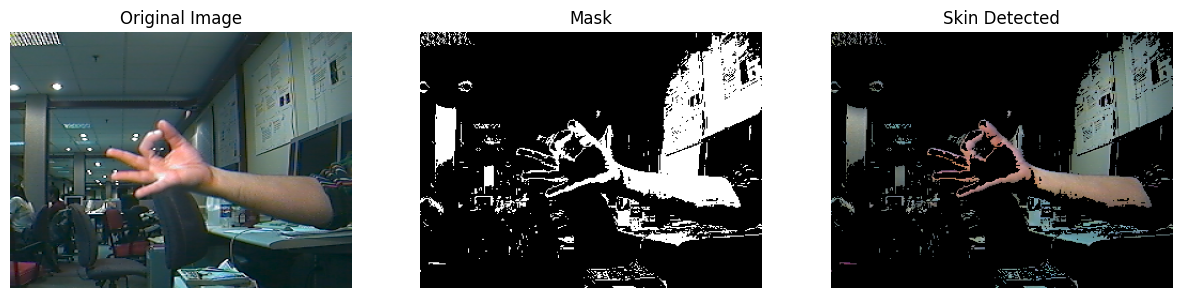

In [2]:
# Read the image
image = cv2.imread('data/frame20.bmp')

# Convert BGR image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define RGB range for skin color
lower_skin = np.array([90, 40, 85], dtype=np.uint8)
upper_skin = np.array([210, 180, 210], dtype=np.uint8)

# Create a mask using inRange function
mask = cv2.inRange(image_rgb, lower_skin, upper_skin)

# Bitwise-AND mask and image
res_rgb = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)

# Display images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Skin Detected")
plt.imshow(res_rgb)
plt.axis("off")

plt.show()

## Probabilistic Models for Skin Detection

In probabilistic models for skin detection we build a model of the distribution of values for skin pixels. Then, we use this model to classify each pixel as skin or non-skin. We assume the skin pixels are distributed according to a Gaussian distribution.

We learn one Gaussian per channel from a patch of skin in `frame2`, and assume the three channels are independent, so that

$$P(RGB \mid skin) = P(R \mid skin)\,P(G \mid skin)\,P(B \mid skin).$$

Then we score every pixel of a different frame, `frame20`, and keep the pixels whose score is above a threshold.

In [3]:
def gaussian_probability(mean, std, values):
    """
    Calculate Gaussian probability based on given mean and standard deviation for each value.
    
    Parameters:
        mean (float): The mean of the distribution.
        std (float): The standard deviation of the distribution.
        values (numpy.ndarray): The array of values for which to calculate the Gaussian probabilities.
        
    Returns:
        numpy.ndarray: The array of Gaussian probabilities for the input values.
    """
    return np.exp(-((values - mean)**2) / (2 * std ** 2)) / (std * np.sqrt(2 * np.pi))

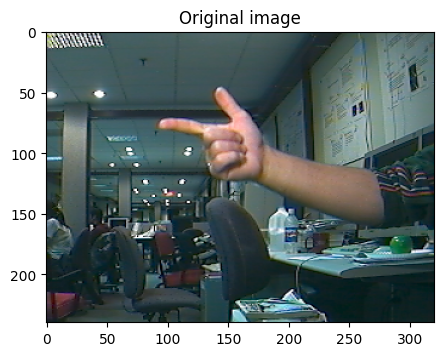

In [4]:
# Read the image
frame2 = cv2.imread('data/frame2.bmp')

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title('Original image')
plt.show()

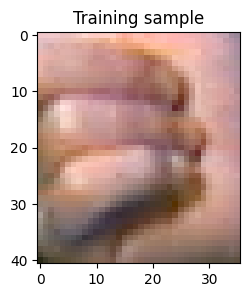

In [5]:
# Get the training sample
sample = frame2[79:120, 136:172].astype(np.float64)

# Display the training sample
plt.figure(figsize=(3, 3))
plt.imshow(cv2.cvtColor(sample.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title('Training sample')
plt.show()

In [6]:
def display_images(original, detection, binary):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(original.astype(np.uint8))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Skin Detection")
    plt.imshow(detection, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Detected Skin Pixels")
    plt.imshow(binary, cmap='gray')
    plt.axis("off")

    plt.show()

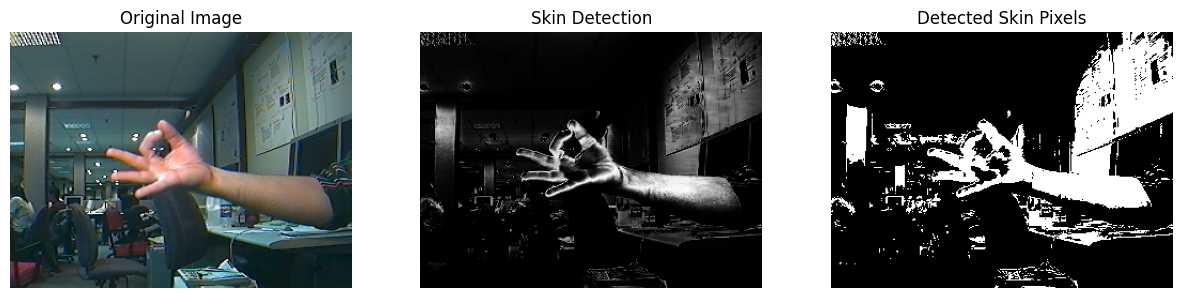

In [7]:
# Extract the colors. cv2.imread gives BGR: red is channel 2
sample_red = sample[:,:,2].ravel() # ravel() flattens the array. Similar to reshape(-1) and flatten().
sample_green = sample[:,:,1].ravel()
sample_blue = sample[:,:,0].ravel()

# Compute mean and std
red_mean = np.mean(sample_red)
green_mean = np.mean(sample_green)
blue_mean = np.mean(sample_blue)
red_std = np.std(sample_red)
green_std = np.std(sample_green)
blue_std = np.std(sample_blue)

# Read another image to apply the model
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)
rows, cols, bands = frame20.shape

skin_detection = np.zeros((rows, cols))

for row in range(rows):
    for col in range(cols):
        red = frame20[row, col, 0]
        green = frame20[row, col, 1]
        blue = frame20[row, col, 2]
        
        red_pr = gaussian_probability(red_mean, red_std, red)
        green_pr = gaussian_probability(green_mean, green_std, green)
        blue_pr = gaussian_probability(blue_mean, blue_std, blue)
        
        prob = red_pr * green_pr * blue_pr
        skin_detection[row, col] = prob     # P(RGB|skin)

# Display images
display_images(frame20, skin_detection, skin_detection > .0000001)


The scores are tiny, which is why the threshold is $10^{-7}$. Each channel's standard deviation is around 40, so each bell curve is wide and low, and the product of three of them is smaller still. The largest score in the frame is below $10^{-6}$.

In [8]:
print("means (R, G, B):", np.round([red_mean, green_mean, blue_mean], 1))
print("stds  (R, G, B):", np.round([red_std, green_std, blue_std], 1))
print("largest score in frame20:", skin_detection.max())
print(f"share of frame20 kept: {np.mean(skin_detection > 1e-7):.1%}")

means (R, G, B): [174.6 133.2 122.7]
stds  (R, G, B): [47.  37.5 39.5]
largest score in frame20: 9.078005355001746e-07
share of frame20 kept: 23.0%


## Normalized Color Spaces

Dividing each channel by the sum of all three removes brightness: doubling R, G and B leaves $r = \frac{R}{R+G+B}$ and $g = \frac{G}{R+G+B}$ unchanged. Two numbers are enough, because $b = 1 - r - g$. A pure-black pixel has no color at all ($R + G + B = 0$), so it is left out of training, and in `frame20` it gets $r = g = 0$, far from any skin color.

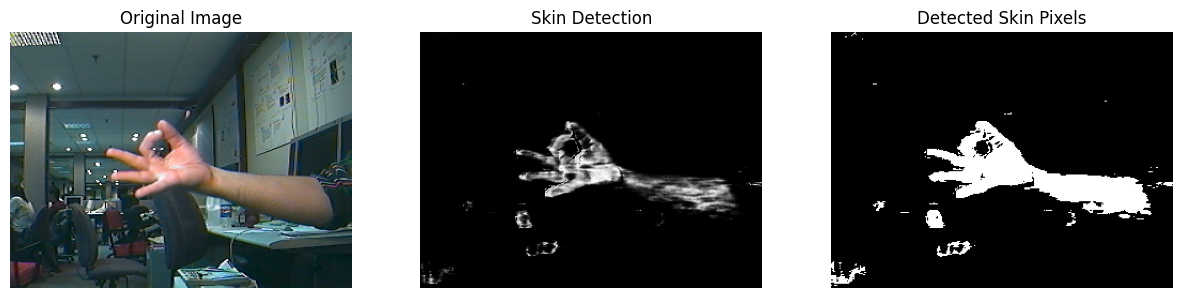

In [9]:
# Read the image
frame2 = cv2.imread('data/frame2.bmp').astype(np.float64)

# Get the training skin sample
sample = frame2[79:120, 136:172]

# Extract the colors
sample_red = sample[:,:,2].ravel()
sample_green = sample[:,:,1].ravel()
sample_blue = sample[:,:,0].ravel()

sample_total = sample_red + sample_green + sample_blue

# Normalize red and green. Skip pure-black pixels (total 0):
# they have no color, and dividing by 0 would give NaN.
keep = sample_total > 0
sample_red2 = sample_red[keep] / sample_total[keep]
sample_green2 = sample_green[keep] / sample_total[keep]

# Compute mean and std in normalized rg space
r_mean = np.mean(sample_red2)
g_mean = np.mean(sample_green2)
r_std = np.std(sample_red2)
g_std = np.std(sample_green2)

# Read another image to apply the model
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)
rows, cols, bands = frame20.shape

skin_detection2 = np.zeros((rows, cols))

for row in range(rows):
    for col in range(cols):
        red = frame20[row, col, 0]
        green = frame20[row, col, 1]
        blue = frame20[row, col, 2]
        
        total = red + green + blue
        if total > 0:
            r = red / total
            g = green / total
        else:
            r = 0
            g = 0
            
        r_prob = gaussian_probability(r_mean, r_std, r)
        g_prob = gaussian_probability(g_mean, g_std, g)
        
        prob = r_prob * g_prob
        skin_detection2[row, col] = prob

# Display images
display_images(frame20, skin_detection2, skin_detection2 > 10)

These scores go far above 1, which is why the threshold is 10 here. $P(rg \mid skin)$ is a probability *density*, not a probability. The hand's r and g barely vary, so each bell curve is narrow and tall: a standard deviation of 0.03 gives a peak of $1 / (0.03\sqrt{2\pi}) \approx 13$. Only areas under a density are probabilities, and those never exceed 1.

In [10]:
print(f"r: mean {r_mean:.3f}, std {r_std:.4f}    g: mean {g_mean:.3f}, std {g_std:.4f}")
print("largest score in frame20:", round(skin_detection2.max(), 1))
print(f"share of frame20 kept: {np.mean(skin_detection2 > 10):.1%}")

r: mean 0.408, std 0.0304    g: mean 0.310, std 0.0134
largest score in frame20: 390.7
share of frame20 kept: 9.5%


## Histogram-based Methods

A histogram assumes no shape for the distribution. The two histograms loaded below were computed in advance from labeled images, one from skin pixels and one from everything else. Each has 32 bins per channel, so a pixel's bin is its value divided by 8 and rounded down, and each is normalized to sum to 1, which makes every entry a probability.

In [11]:
positive_histogram = np.load('data/positive_histogram.npy')   # P(RGB | skin)
negative_histogram = np.load('data/negative_histogram.npy')   # P(RGB | non-skin)

print("shape:", positive_histogram.shape)
print("sums:", positive_histogram.sum(), negative_histogram.sum())
print(f"non-empty bins: skin {np.mean(positive_histogram > 0):.0%}, non-skin {np.mean(negative_histogram > 0):.0%}")
peak = np.unravel_index(np.argmax(positive_histogram), positive_histogram.shape)
print("largest skin bin:", tuple(int(i) for i in peak), "holds", positive_histogram[peak])

shape: (32, 32, 32)
sums: 0.9999999999999999 1.0
non-empty bins: skin 53%, non-skin 99%
largest skin bin: (31, 31, 31) holds 0.0026621836923080336


The largest skin bin is $(31, 31, 31)$, pure white: the skin photos contain many overexposed highlights. Keep that in mind when you look at the results below.

#### Using only positive histogram

In [12]:
def detect_skin2(image, positive_histogram):
    """
    Detect skin in the given image based on a precomputed positive_histogram.
    
    Parameters:
        image (numpy.ndarray): The input image array with shape (vertical_size, horizontal_size, 3).
        positive_histogram (numpy.ndarray): The precomputed positive histogram for skin detection.
        
    Returns:
        numpy.ndarray: The result of skin detection, an array with shape (vertical_size, horizontal_size).
    """

    vertical_size, horizontal_size, _ = image.shape
    histogram_bins = positive_histogram.shape[0]
    factor = 256 / histogram_bins
    
    result = np.zeros((vertical_size, horizontal_size))
    
    for vertical in range(vertical_size):
        for horizontal in range(horizontal_size):
            red = image[vertical, horizontal, 0]
            green = image[vertical, horizontal, 1]
            blue = image[vertical, horizontal, 2]
            
            r_index = int(np.floor(red / factor))
            g_index = int(np.floor(green / factor))
            b_index = int(np.floor(blue / factor))
            
            skin_value = positive_histogram[r_index, g_index, b_index]
            result[vertical, horizontal] = skin_value
            
    return result

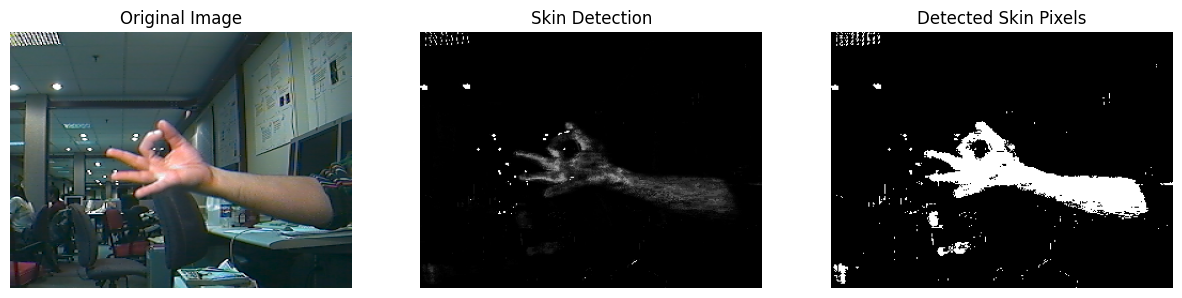

In [13]:
# Load positive skin histogram
positive_histogram = np.load('data/positive_histogram.npy')

# Read the image
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)

# Detect skin
result = detect_skin2(frame20, positive_histogram)

# Display images
display_images(frame20, result, result > 0.0001)

Besides the hand and the arm, the mask keeps the ceiling lights (the striped panel at the top left and the small lamps along the ceiling) and scattered specks of background. The skin histogram only says how common a color is *among skin pixels*, and pure white is its most common color. It says nothing about how common a color is everywhere else.

#### Using both positive and negative histograms

Bayes' rule turns the two likelihoods into the probability we want:

$$P(skin \mid RGB) = \frac{P(RGB \mid skin)\,P(skin)}{P(RGB \mid skin)\,P(skin) + P(RGB \mid non\text{-}skin)\,P(non\text{-}skin)}.$$

`detect_skin` assumes $P(skin) = P(non\text{-}skin) = 0.5$, so the priors cancel and the posterior is the skin bin divided by the sum of the two bins.

In [14]:
def detect_skin(image, positive_histogram, negative_histogram):
    """
    Detects skin in an image using positive and negative histograms.
    
    Parameters:
        image (numpy.ndarray): The input image array with shape (height, width, 3).
        positive_histogram (numpy.ndarray): The positive histogram.
        negative_histogram (numpy.ndarray): The negative histogram.
        
    Returns:
        numpy.ndarray: The output array with skin detection probabilities, shape (height, width).
    """
    
    vertical_size, horizontal_size, _ = image.shape
    histogram_bins = positive_histogram.shape[0]
    factor = 256 / histogram_bins
    
    result = np.zeros((vertical_size, horizontal_size))
    
    for vertical in range(vertical_size):
        for horizontal in range(horizontal_size):
            red = float(image[vertical, horizontal, 0])
            green = float(image[vertical, horizontal, 1])
            blue = float(image[vertical, horizontal, 2])
            
            red_index = int(np.floor(red / factor))
            green_index = int(np.floor(green / factor))
            blue_index = int(np.floor(blue / factor))
            
            skin_value = positive_histogram[red_index, green_index, blue_index]     # P(RGB | skin)
            non_skin_value = negative_histogram[red_index, green_index, blue_index] # P(RGB | non-skin)
            total = skin_value + non_skin_value
            
            if total != 0:
                # Bayes rule: P(skin | RGB) = P(RGB | skin) / (P(RGB | skin) + P(RGB | non-skin)) 
                # P(skin) = P(non-skin) = 0.5 are assumed to be equal and thus ignored.
                result[vertical, horizontal] = skin_value / total 
                
    return result


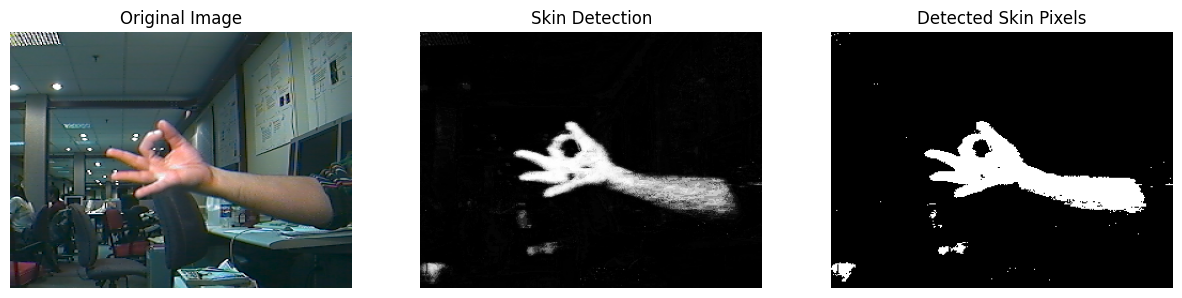

In [15]:
# Read histograms
negative_histogram = np.load('data/negative_histogram.npy')
positive_histogram = np.load('data/positive_histogram.npy')

# Read the image
frame20 = cv2.imread('data/frame20.bmp')
frame20 = cv2.cvtColor(frame20, cv2.COLOR_BGR2RGB).astype(np.float64)

# Detect skin
result = detect_skin(frame20, positive_histogram, negative_histogram)

# Display images
display_images(frame20, result, result > 0.2)

The ceiling lights are gone. White is common among skin pixels, but far more common among everything else, so its posterior is low: about 0.07 for a pixel of a ceiling lamp.

## The Same Detectors Without Loops

The loops above visit the 76,800 pixels of `frame20` one at a time, which keeps each step visible but is slow in Python. NumPy can do every step on the whole image at once: `gaussian_probability` already works on arrays, `np.divide` with `out=` and `where=` handles the black pixels, and *fancy indexing* looks up the histogram bin of every pixel in one expression. The cell checks that each result matches the loop version.

In [16]:
import time

rgb = frame20                                    # float64, RGB order (from the cell above)

# Gaussian in RGB
fast_rgb = (gaussian_probability(red_mean, red_std, rgb[:, :, 0]) *
            gaussian_probability(green_mean, green_std, rgb[:, :, 1]) *
            gaussian_probability(blue_mean, blue_std, rgb[:, :, 2]))

# Gaussian in rg; black pixels get r = g = 0, as in the loop
total = rgb.sum(axis=2)
r = np.divide(rgb[:, :, 0], total, out=np.zeros_like(total), where=total > 0)
g = np.divide(rgb[:, :, 1], total, out=np.zeros_like(total), where=total > 0)
fast_rg = gaussian_probability(r_mean, r_std, r) * gaussian_probability(g_mean, g_std, g)

# Histograms: the bin of every pixel, then one lookup per histogram
idx = (rgb // 8).astype(int)                     # shape (rows, cols, 3)
p_skin = positive_histogram[idx[:, :, 0], idx[:, :, 1], idx[:, :, 2]]   # P(RGB | skin)
p_non = negative_histogram[idx[:, :, 0], idx[:, :, 1], idx[:, :, 2]]    # P(RGB | non-skin)
total_hist = p_skin + p_non
fast_post = np.divide(p_skin, total_hist, out=np.zeros_like(total_hist), where=total_hist > 0)

print("Gaussian RGB matches the loop:", np.allclose(fast_rgb, skin_detection))
print("Gaussian rg matches the loop: ", np.allclose(fast_rg, skin_detection2))
print("posterior matches detect_skin:", np.allclose(fast_post, result))

start = time.perf_counter()
loop_hist = detect_skin2(frame20, positive_histogram)
loop_ms = 1000 * (time.perf_counter() - start)
start = time.perf_counter()
fast_hist = positive_histogram[idx[:, :, 0], idx[:, :, 1], idx[:, :, 2]]
fast_ms = 1000 * (time.perf_counter() - start)
print(f"skin histogram: loops {loop_ms:.0f} ms, NumPy {fast_ms:.2f} ms, identical: {np.array_equal(loop_hist, fast_hist)}")

Gaussian RGB matches the loop: True
Gaussian rg matches the loop:  True
posterior matches detect_skin: True
skin histogram: loops 206 ms, NumPy 0.68 ms, identical: True
skin histogram: loops 206 ms, NumPy 0.68 ms, identical: True


## Changing the Prior $P(skin)$

A prior of 0.5 says half of all pixels are skin, which is far too high for most photos. Here is the posterior for any prior, using `p_skin` and `p_non` from the cell above.

In [17]:
def posterior(prior):
    """P(skin | RGB) for every pixel of frame20, given P(skin) = prior."""
    den = prior * p_skin + (1 - prior) * p_non
    return np.divide(prior * p_skin, den, out=np.zeros_like(den), where=den > 0)

for prior in (0.5, 0.1):
    print(f"P(skin) = {prior}: posterior > 0.2 keeps {np.mean(posterior(prior) > 0.2):.1%} of frame20")

P(skin) = 0.5: posterior > 0.2 keeps 8.8% of frame20
P(skin) = 0.1: posterior > 0.2 keeps 5.0% of frame20


A lower prior lowers every posterior, so the same threshold keeps fewer pixels. But it lowers them all in the same way: Bayes' rule multiplies the posterior *odds* $\frac{P(skin \mid RGB)}{P(non\text{-}skin \mid RGB)}$ by the prior odds, the same factor for every pixel. So for every prior there is a threshold that keeps exactly the same pixels as prior 0.5 with threshold 0.2. Changing the prior only moves the threshold.

In [18]:
# threshold 0.2 at prior 0.5 means posterior odds above 0.2 / 0.8 = 0.25
# prior 0.1 multiplies every pixel's odds by (0.1 / 0.9) / (0.5 / 0.5) = 1 / 9
odds = 0.25 / 9
matched = odds / (1 + odds)
print(f"matched threshold for P(skin) = 0.1: {matched:.4f}")
print("same mask as prior 0.5 with threshold 0.2:",
      np.array_equal(posterior(0.1) > matched, posterior(0.5) > 0.2))

matched threshold for P(skin) = 0.1: 0.0270
same mask as prior 0.5 with threshold 0.2: True


## Try It Yourself

1. Change the training sample, `frame2[79:120, 136:172]`, to a patch of the wall behind the person, for example `frame2[40:90, 196:216]`, and run the Gaussian RGB cells again. What does the "skin" detector find now?
2. Make each threshold (1e-7, 10, 0.0001 and 0.2) ten times larger and ten times smaller. Which detector is the most sensitive to its threshold?
3. Estimate what fraction of `frame20` is skin, use it as the prior, and find the threshold that gives the cleanest mask.
4. The histograms were built from a set of labeled photos you cannot see. If you used them on a photo of someone whose skin tone was rare in those photos, which of the five detectors would you trust least, and why?